Memory before: 3766.7 MB
Memory after:  1992.0 MB  (↓47%)
Shape train: (5337414, 94)
Stats computed.
>>> Building features and fitting RF by horizon...

  HORIZON 1
  Фич: 553  Строк: 1394653
  y std: 11.9741  w sum: 1.63e+12  w zeros: 81
  X shape: (100000, 553)  NaN: 0  Inf: 0
  Importance sum: 1.0000  NaN: 0

  HORIZON 3
  Фич: 553  Строк: 1385816
  y std: 19.2328  w sum: 1.37e+12  w zeros: 103
  X shape: (100000, 553)  NaN: 0  Inf: 0
  Importance sum: 1.0000  NaN: 0

  HORIZON 10
  Фич: 553  Строк: 1337236
  y std: 33.7955  w sum: 1.12e+12  w zeros: 76
  X shape: (100000, 553)  NaN: 0  Inf: 0
  Importance sum: 1.0000  NaN: 0

  HORIZON 25
  Фич: 553  Строк: 1219709
  y std: 51.6242  w sum: 1.42e+12  w zeros: 114
  X shape: (100000, 553)  NaN: 0  Inf: 0
  Importance sum: 1.0000  NaN: 0

==================================================  HORIZON 1  ==================================================
  Всего фич: 553  Raw: 85  Engineered: 468
    lags:              222
    rolling:   

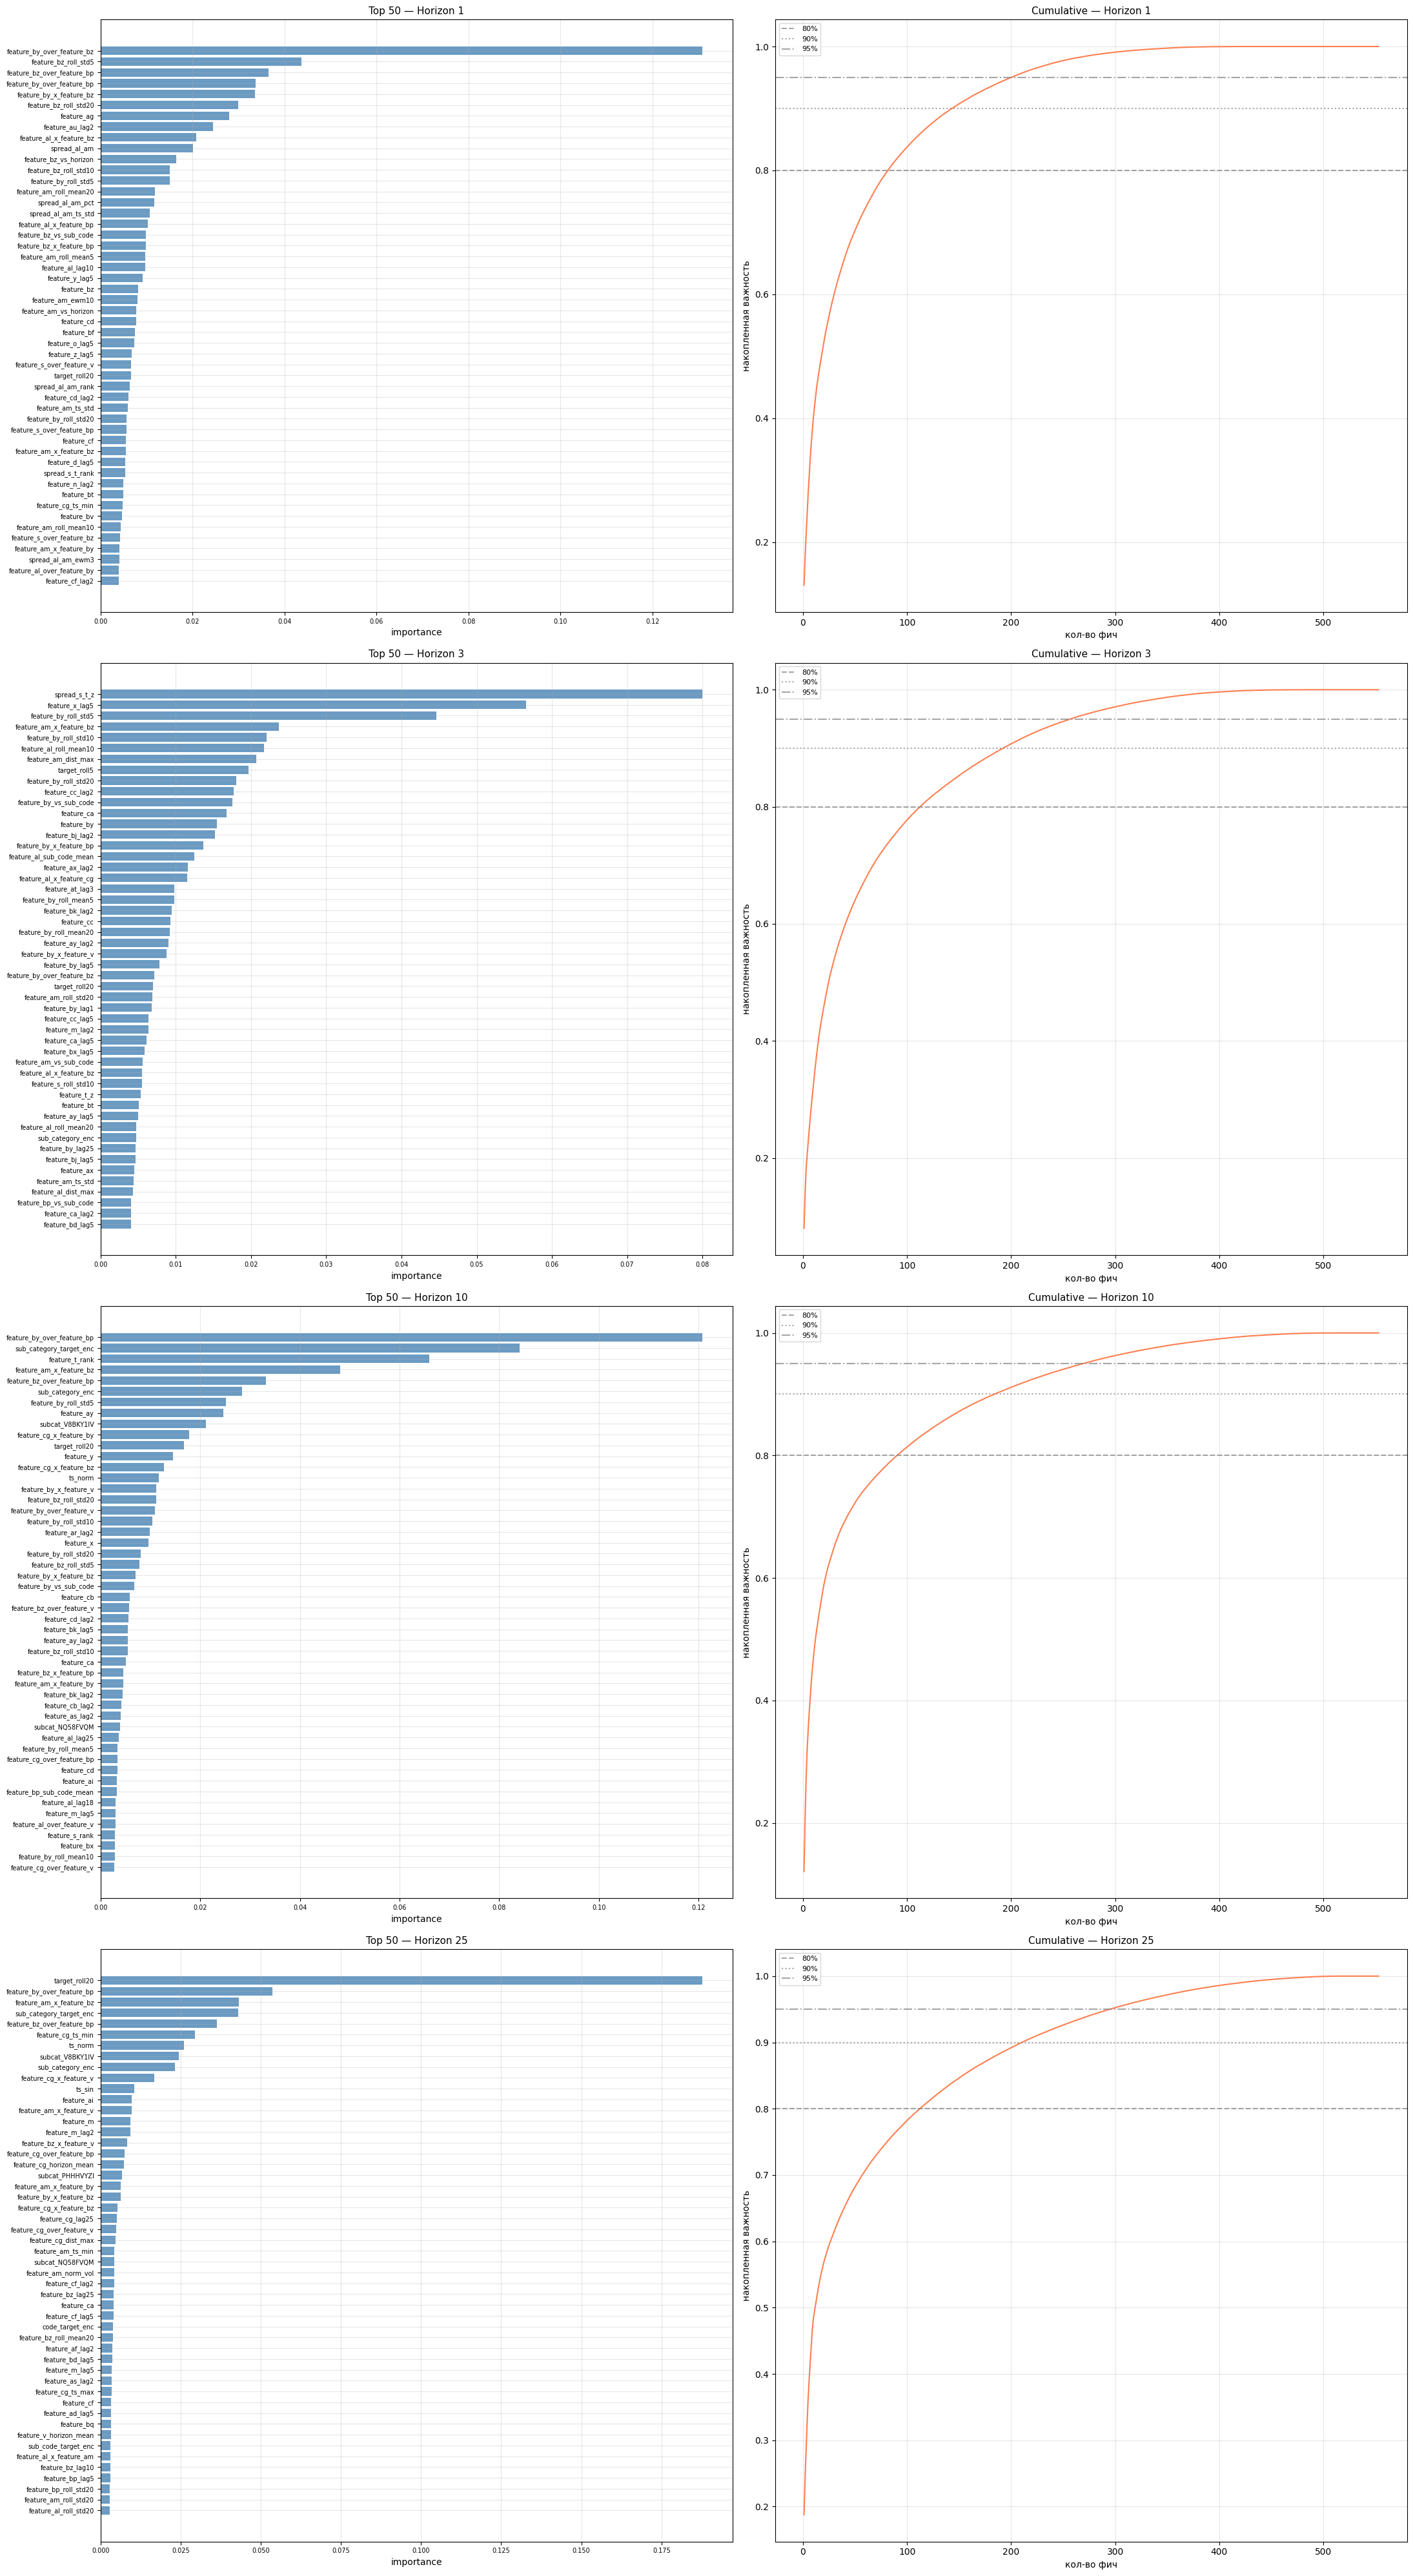

Hz 1: 553 фич
Hz 3: 553 фич
Hz 10: 553 фич
Hz 25: 553 фич
Saved: selected_features_per_horizon.json

Union всех горизонтов: 556 уникальных фич
Saved: selected_features_union.json
Saved: selected_features_hz*.csv


In [1]:
#%%
# ── ИМПОРТЫ ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import gc
from sklearn.ensemble import RandomForestRegressor

#%%
# ── ЗАГРУЗКА С ОПТИМИЗАЦИЕЙ ПАМЯТИ ───────────────────────────────────────────
def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    start_mem = df.memory_usage().sum() / 1024 ** 2
    print(f"Memory before: {start_mem:.1f} MB")
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object:
            df[col] = df[col].astype("category")
        elif str(col_type)[:3] == "int":
            c_min, c_max = df[col].min(), df[col].max()
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            else:
                df[col] = df[col].astype(np.int32)
        elif str(col_type)[:5] == "float":
            c_min, c_max = df[col].min(), df[col].max()
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage().sum() / 1024 ** 2
    print(f"Memory after:  {end_mem:.1f} MB  (↓{100*(start_mem-end_mem)/start_mem:.0f}%)")
    return df

train = pd.read_parquet('/kaggle/input/competitions/ts-forecasting/train.parquet')
train = reduce_mem_usage(train)
train = train.sort_values("ts_index").reset_index(drop=True)
gc.collect()

TARGET_COL = "y_target"
WEIGHT_COL = "weight"

print("Shape train:", train.shape)

#%%
# ── ПРЕДВЫЧИСЛЕНИЕ СТАТИСТИК ──────────────────────────────────────────────────
VAL_CUTOFF = int(train["ts_index"].quantile(0.80))
train_fit  = train[train["ts_index"] <= VAL_CUTOFF]

freq_stats = {
    "sub_code_freq":      train_fit["sub_code"].value_counts().to_dict(),
    "sub_code_freq_rank": train_fit["sub_code"].value_counts().rank(ascending=False).to_dict(),
}

target_stats = {
    'sub_category': train_fit.groupby('sub_category', observed=True)[TARGET_COL].mean().to_dict(),
    'sub_code':     train_fit.groupby('sub_code', observed=True)[TARGET_COL].mean().to_dict(),
    'code':         train_fit.groupby('code', observed=True)[TARGET_COL].mean().to_dict(),
    'global_mean':  float(train_fit[TARGET_COL].mean()),
}

del train_fit
gc.collect()
print("Stats computed.")

#%%
# ── CREATE_FEATURES ───────────────────────────────────────────────────────────
def create_features(df, freq_stats=None, target_stats=None, horizon=1):
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype(np.float32)

    df = df.sort_values(['code', 'sub_code', 'ts_index']).reset_index(drop=True)
    raw_feature_cols = [c for c in df.columns if c.startswith('feature_')]

    # ── GROUP 1: One-Hot sub_category ────────────────────────────────────────
    sub_cat_dummies = pd.get_dummies(df['sub_category'], prefix='subcat', dtype=np.int8)
    for c in sub_cat_dummies.columns:
        df[c] = sub_cat_dummies[c].values
    del sub_cat_dummies; gc.collect()

    # ── GROUP 2: Frequency encoding sub_code ─────────────────────────────────
    if freq_stats is not None:
        freq_arr      = df['sub_code'].map(freq_stats['sub_code_freq']).fillna(1).astype(np.float32).values
        freq_rank_arr = df['sub_code'].map(freq_stats['sub_code_freq_rank']).fillna(df['sub_code'].nunique()).astype(np.float32).values
        ts_freq_arr   = df.groupby(['ts_index', 'sub_code'], observed=True)['sub_code'].transform('count').astype(np.float32).values
        df['sub_code_freq']      = freq_arr
        df['sub_code_log_freq']  = np.log1p(freq_arr)
        df['sub_code_freq_rank'] = freq_rank_arr
        df['sub_code_ts_freq']   = ts_freq_arr
        df['sub_code_rel_freq']  = ts_freq_arr / (freq_arr + 1)
        del freq_arr, freq_rank_arr, ts_freq_arr; gc.collect()

    # ── GROUP 3: Spreads & Ratios ─────────────────────────────────────────────
    df['spread_al_am'] = (df['feature_al'] - df['feature_am']).astype(np.float32)
    df['ratio_al_am']  = (df['feature_al'] / (df['feature_am'] + 1e-7)).astype(np.float32)
    df['spread_cg_by'] = (df['feature_cg'] - df['feature_by']).astype(np.float32)
    df['ratio_cg_by']  = (df['feature_cg'] / (df['feature_by'] + 1e-7)).astype(np.float32)
    df['spread_s_t']   = (df['feature_s']  - df['feature_t']).astype(np.float32)
    df['ratio_s_t']    = (df['feature_s']  / (df['feature_t']  + 1e-7)).astype(np.float32)
    gc.collect()

    # ── GROUP 4: EWM momentum ────────────────────────────────────────────────
    ewm_spans = [3, 5] if horizon <= 3 else [5, 7]
    g2 = df.groupby(['code', 'sub_code'], sort=False, observed=True)
    for f in ['feature_al', 'feature_am', 'spread_al_am']:
        if f in df.columns:
            for span in ewm_spans:
                df[f'{f}_ewm{span}'] = g2[f].transform(
                    lambda x, s=span: x.ewm(span=s, adjust=False).mean()
                ).astype(np.float32)
    g4 = df.groupby(['code', 'sub_code', 'sub_category', 'horizon'], sort=False, observed=True)
    for f in ['feature_al', 'feature_am', 'feature_cg', 'feature_by']:
        if f in df.columns:
            df[f'{f}_ewm10'] = g4[f].transform(
                lambda x: x.ewm(span=10, adjust=False).mean()
            ).astype(np.float32)
    del g2, g4; gc.collect()

    # ── GROUP 5: Volatility ───────────────────────────────────────────────────
    for f in ['feature_al', 'feature_am', 'spread_al_am']:
        if f in df.columns:
            std = df.groupby('ts_index')[f].transform('std').astype(np.float32)
            df[f'{f}_ts_std']   = std.values
            df[f'{f}_norm_vol'] = (df[f] / (std + 1e-7)).astype(np.float32)
            del std
    gc.collect()

    # ── GROUP 6: Min/Max extremes ─────────────────────────────────────────────
    for f in ['feature_al', 'feature_am', 'feature_cg']:
        if f in df.columns:
            ts_min = df.groupby('ts_index')[f].transform('min').astype(np.float32)
            ts_max = df.groupby('ts_index')[f].transform('max').astype(np.float32)
            df[f'{f}_ts_min']   = ts_min.values
            df[f'{f}_ts_max']   = ts_max.values
            df[f'{f}_ts_range'] = (ts_max - ts_min).values
            df[f'{f}_dist_min'] = (df[f] - ts_min).astype(np.float32)
            df[f'{f}_dist_max'] = (ts_max - df[f]).astype(np.float32)
            del ts_min, ts_max
    gc.collect()

    # ── GROUP 7: Momentum diff & pct ─────────────────────────────────────────
    g7 = df.groupby(['code', 'sub_code'], sort=False, observed=True)
    for f in ['feature_al', 'spread_al_am']:
        if f in df.columns:
            df[f'{f}_diff'] = g7[f].diff().astype(np.float32)
            df[f'{f}_pct']  = g7[f].pct_change(fill_method=None).fillna(0).astype(np.float32)
    del g7; gc.collect()

    # ── GROUP 8: Cross-sectional Z-scores ─────────────────────────────────────
    for f in ['feature_al', 'feature_am', 'feature_cg', 'feature_by',
              'feature_s', 'feature_t',
              'spread_al_am', 'spread_cg_by', 'spread_s_t']:
        if f in df.columns:
            mean = df.groupby('ts_index')[f].transform('mean').astype(np.float32)
            std  = df.groupby('ts_index')[f].transform('std').astype(np.float32)
            df[f'{f}_z'] = ((df[f] - mean) / (std + 1e-7)).astype(np.float32)
            del mean, std
    gc.collect()

    # ── GROUP 9: Percentile rank ──────────────────────────────────────────────
    for f in ['feature_al', 'feature_am', 'feature_cg', 'feature_by',
              'feature_s', 'feature_t',
              'spread_al_am', 'spread_cg_by', 'spread_s_t']:
        if f in df.columns:
            df[f'{f}_rank'] = df.groupby('ts_index')[f].rank(pct=True).astype(np.float32)
    gc.collect()

    # ── GROUP 10: Cyclical time encoding ──────────────────────────────────────
    df['ts_sin'] = np.sin(2 * np.pi * df['ts_index'] / 100).astype(np.float32)
    df['ts_cos'] = np.cos(2 * np.pi * df['ts_index'] / 100).astype(np.float32)

    # ── GROUP 11: Target encoding ─────────────────────────────────────────────
    if target_stats is not None:
        for c in ['sub_category', 'sub_code', 'code']:
            if c in target_stats:
                df[f'{c}_target_enc'] = df[c].astype(str).map(target_stats[c]).fillna(
                    target_stats.get('global_mean', 0)
                ).astype(np.float32)

    # ── GROUP 14: feature_s interactions ──────────────────────────────────────
    if 'feature_s' in df.columns:
        df['s_al_prod'] = (df['feature_s'] * df['feature_al']).astype(np.float32)
        df['s_am_prod'] = (df['feature_s'] * df['feature_am']).astype(np.float32)
        df['s_cg_prod'] = (df['feature_s'] * df['feature_cg']).astype(np.float32)

    # ── GROUP 17: Row-level statistics ────────────────────────────────────────
    feat_vals = df[raw_feature_cols].values.astype(np.float32)
    df['row_mean']      = np.nanmean(feat_vals, axis=1).astype(np.float32)
    df['row_std']       = np.nanstd(feat_vals, axis=1).astype(np.float32)
    df['row_range']     = (np.nanmax(feat_vals, axis=1) - np.nanmin(feat_vals, axis=1)).astype(np.float32)
    df['row_nan_count'] = np.isnan(feat_vals).sum(axis=1).astype(np.float32)
    del feat_vals; gc.collect()

    # ── GROUP 18: Horizon numeric ─────────────────────────────────────────────
    df['horizon_num'] = df['horizon'].astype(np.float32)
    df['horizon_log'] = np.log1p(df['horizon'].astype(np.float32))

    # ── GROUP 19: ts_norm + label encodings ───────────────────────────────────
    tmin = float(df['ts_index'].min())
    tmax = float(df['ts_index'].max())
    df['ts_norm']          = ((df['ts_index'] - tmin) / (tmax - tmin + 1e-6)).astype(np.float32)
    df['code_enc']         = df['code'].astype('category').cat.codes.astype(np.float32)
    df['sub_code_enc']     = df['sub_code'].astype('category').cat.codes.astype(np.float32)
    df['sub_category_enc'] = df['sub_category'].astype('category').cat.codes.astype(np.float32)

    # ── GROUP 20: Rolling target с shift — без лика ───────────────────────────
    grp_target = ['code', 'sub_code', 'sub_category']
    g_tgt = df.groupby(grp_target, sort=False, observed=True)
    for w_roll in [5, 20]:
        df[f'target_roll{w_roll}'] = g_tgt[TARGET_COL].transform(
            lambda x, w=w_roll, h=horizon: x.shift(h).rolling(w, min_periods=1).mean()
        ).astype(np.float32)
    del g_tgt; gc.collect()

   # ── GROUP 12 + 12-EXT: Все лаги ──────────────────────────────────────────
    group_cols = ['code', 'sub_code', 'sub_category', 'horizon']
    top_feats_for_lags = [
        'feature_al', 'feature_am', 'feature_cg', 'feature_by', 'feature_s',
        'feature_bp', 'feature_bz', 'feature_aq', 'feature_at', 'feature_v',
    ]
    df = df.sort_values(group_cols + ['ts_index']).reset_index(drop=True)
    g_lag = df.groupby(group_cols, sort=False, observed=True)

    lag_new = {}
    for lag in [1, 3, 5, 10, 25]:
        for col in top_feats_for_lags:
            if col in df.columns:
                lag_new[f'{col}_lag{lag}'] = g_lag[col].shift(lag).astype(np.float32).values

    for lag in [2, 6, 12, 18, 24]:
        for col in ['feature_al', 'feature_am', 'feature_cg', 'feature_by']:
            if col in df.columns:
                lag_new[f'{col}_lag{lag}'] = g_lag[col].shift(lag).astype(np.float32).values

    already_have_lags = set(top_feats_for_lags) | {'feature_al', 'feature_am', 'feature_cg', 'feature_by'}
    remaining_feats = [c for c in raw_feature_cols if c not in already_have_lags]
    for lag in [2, 5]:
        for col in remaining_feats:
            if col in df.columns:
                lag_new[f'{col}_lag{lag}'] = g_lag[col].shift(lag).astype(np.float32).values

    del g_lag
    df = pd.concat([df, pd.DataFrame(lag_new, index=df.index)], axis=1)
    del lag_new;
    df = df.copy()  # ← дефрагментация
    gc.collect()

    # ── GROUP 13 + 13-EXT: Все rolling ───────────────────────────────────────
    # ── GROUP 13: Rolling mean/std только для top_feats_for_lags ─────────────
    g_roll = df.groupby(group_cols, sort=False, observed=True)
    roll_new = {}

    for col in top_feats_for_lags:
        if col not in df.columns:
            continue
        for w in [5, 10, 20]:
            roll_new[f'{col}_roll_mean{w}'] = g_roll[col].transform(
                lambda x, w=w: x.rolling(w, min_periods=1).mean()
            ).astype(np.float32).values
            roll_new[f'{col}_roll_std{w}'] = g_roll[col].transform(
                lambda x, w=w: x.rolling(w, min_periods=1).std()
            ).astype(np.float32).values

    # GROUP 13-EXT удалена — rolling для remaining_feats убрана
    del g_roll
    df = pd.concat([df, pd.DataFrame(roll_new, index=df.index)], axis=1)
    del roll_new; gc.collect()

    # ── GROUP 16: Hierarchical deviation — ВСЕ raw фичи ──────────────────────
    hier_feats_all = [
        'feature_al', 'feature_am', 'feature_by', 'feature_bz', 'feature_v',
        'feature_aq', 'feature_s', 'feature_t', 'feature_bp', 'feature_cg',
    ]
    for h in ['sub_code', 'horizon']:
        hier_new = {}
        grp = df.groupby([h, 'ts_index'], sort=False, observed=True)
        for col in hier_feats_all:
            if col in df.columns:
                mean_vals = grp[col].transform('mean').astype(np.float32)
                hier_new[f'{col}_{h}_mean'] = mean_vals.values
                hier_new[f'{col}_vs_{h}']   = (df[col] - mean_vals).astype(np.float32).values
                del mean_vals
        df = pd.concat([df, pd.DataFrame(hier_new, index=df.index)], axis=1)
        del hier_new; gc.collect()

    # ── GROUP 21: Попарные interactions топ-15 фич — батчами ─────────────────
    interaction_feats = [
        'feature_al', 'feature_am', 'feature_cg', 'feature_by',
        'feature_s',  'feature_bz', 'feature_v',  'feature_bp',
    ]
    EPS = 1e-3
    pairs = [
        (interaction_feats[i], interaction_feats[j])
        for i in range(len(interaction_feats))
        for j in range(i + 1, len(interaction_feats))
    ]
    BATCH = 50
    for start in range(0, len(pairs), BATCH):
        for f1, f2 in pairs[start:start + BATCH]:
            if f1 in df.columns and f2 in df.columns:
                df[f'{f1}_x_{f2}']    = (df[f1] * df[f2]).astype(np.float32)
                df[f'{f1}_over_{f2}'] = (df[f1] / (df[f2].abs() + EPS)).astype(np.float32)
        gc.collect()

    # ── финальная очистка ─────────────────────────────────────────────────────
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], 0).fillna(0)
    return df

#%%
# ── ПОДГОТОВКА И RF IMPORTANCE ПО ГОРИЗОНТАМ — БЕЗ ХРАНЕНИЯ ВСЕХ FE В RAM ────
EXCLUDE = {"id", "ts_index", TARGET_COL, WEIGHT_COL,
           "code", "sub_code", "sub_category", "horizon"}

importances_per_hz = {}

print(">>> Building features and fitting RF by horizon...")

for hz in [1, 3, 10, 25]:
    print(f"\n{'='*50}\n  HORIZON {hz}\n{'='*50}")

    chunk = train[train["horizon"] == hz].copy()
    fe = create_features(chunk, freq_stats=freq_stats,
                         target_stats=target_stats, horizon=hz)
    del chunk; gc.collect()

    all_features = [c for c in fe.columns if c not in EXCLUDE]
    print(f"  Фич: {len(all_features)}  Строк: {len(fe)}")

    sample = fe.sample(min(100_000, len(fe)), random_state=42)
    del fe; gc.collect()  # ← освобождаем fe сразу после sample

    X = sample[all_features].fillna(0).replace([np.inf, -np.inf], 0).astype(np.float64)
    y = sample[TARGET_COL].values
    w = sample[WEIGHT_COL].values.copy()
    del sample; gc.collect()

    print(f"  y std: {y.std():.4f}  w sum: {w.sum():.2e}  w zeros: {(w==0).sum()}")

    clip_pct = 95 if hz == 25 else 99
    w = np.clip(w, 0, np.percentile(w[w > 0], clip_pct))
    w = w / np.mean(w)

    print(f"  X shape: {X.shape}  NaN: {np.isnan(X.values).sum()}  Inf: {np.isinf(X.values).sum()}")

    rf = RandomForestRegressor(n_estimators=100, max_depth=6, n_jobs=-1, random_state=42)
    rf.fit(X, y, sample_weight=w)

    print(f"  Importance sum: {rf.feature_importances_.sum():.4f}  NaN: {np.isnan(rf.feature_importances_).sum()}")

    imp = pd.DataFrame({
        "feature":    all_features,
        "importance": rf.feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    imp.insert(0, "rank", range(1, len(imp) + 1))
    imp["importance"] = imp["importance"].round(6)
    imp["cumsum"]     = (imp["importance"].cumsum() / imp["importance"].sum()).round(4)

    importances_per_hz[hz] = imp

    del X, y, w, rf; gc.collect()

#%%
# ── ВЫВОД ПО КАЖДОМУ ГОРИЗОНТУ ───────────────────────────────────────────────
for hz in [1, 3, 10, 25]:
    imp = importances_per_hz[hz]
    all_features = imp["feature"].tolist()  # берём из imp — там все фичи

    raw_feats = [f for f in all_features if f.startswith("feature_")
                 and not any(x in f for x in ["_z","_rank","_ewm","_diff",
                                               "_pct","_norm","_ts_","_dist",
                                               "_lag","_roll","_vs_","_prod",
                                               "_mean","_x_","_over_"])]
    eng_feats = [f for f in all_features if f not in raw_feats]

    print(f"\n{'='*50}  HORIZON {hz}  {'='*50}")
    print(f"  Всего фич: {len(all_features)}  Raw: {len(raw_feats)}  Engineered: {len(eng_feats)}")
    print(f"    lags:              {len([f for f in eng_feats if '_lag' in f])}")
    print(f"    rolling:           {len([f for f in eng_feats if '_roll' in f])}")
    print(f"    EWM:               {len([f for f in eng_feats if '_ewm' in f])}")
    print(f"    z-scores:          {len([f for f in eng_feats if '_z' in f and '_z_' not in f])}")
    print(f"    rank:              {len([f for f in eng_feats if '_rank' in f])}")
    print(f"    spreads/ratios:    {len([f for f in eng_feats if 'spread' in f or 'ratio' in f])}")
    print(f"    volatility:        {len([f for f in eng_feats if '_ts_std' in f or '_norm_vol' in f])}")
    print(f"    min/max:           {len([f for f in eng_feats if any(x in f for x in ['_ts_min','_ts_max','_dist','_ts_range'])])}")
    print(f"    momentum:          {len([f for f in eng_feats if '_diff' in f or '_pct' in f])}")
    print(f"    hierarchical _vs_: {len([f for f in eng_feats if '_vs_' in f])}")
    print(f"    hierarchical mean: {len([f for f in eng_feats if '_mean' in f and '_vs_' not in f and 'row_' not in f])}")
    print(f"    target enc:        {len([f for f in eng_feats if '_target_enc' in f])}")
    print(f"    target roll:       {len([f for f in eng_feats if 'target_roll' in f])}")
    print(f"    freq enc:          {len([f for f in eng_feats if 'sub_code_freq' in f or 'sub_code_log' in f or 'sub_code_rel' in f or 'sub_code_ts' in f])}")
    print(f"    one-hot:           {len([f for f in eng_feats if 'subcat' in f])}")
    print(f"    s_prod:            {len([f for f in eng_feats if '_prod' in f])}")
    print(f"    interactions _x_:  {len([f for f in eng_feats if '_x_' in f])}")
    print(f"    interactions over: {len([f for f in eng_feats if '_over_' in f])}")
    print(f"    row stats:         {len([f for f in eng_feats if 'row_' in f])}")
    print(f"    time/horizon:      {len([f for f in eng_feats if 'ts_sin' in f or 'ts_cos' in f or 'horizon_' in f or 'ts_norm' in f])}")
    print(f"    label enc:         {len([f for f in eng_feats if '_enc' in f and 'sub_code_freq' not in f])}")

    print(f"\n  Порог накопленной важности:")
    for threshold in [0.80, 0.90, 0.95, 0.99]:
        n = (imp["cumsum"] <= threshold).sum() + 1
        print(f"    {int(threshold*100)}% → {n} фич")

    pd.set_option("display.max_rows", None)
    print(f"\n  Топ-30 фич:")
    print(imp.head(30).to_string(index=False))
    pd.reset_option("display.max_rows")

#%%
# ── ВИЗУАЛИЗАЦИЯ ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(22, 40))

for idx, hz in enumerate([1, 3, 10, 25]):
    imp = importances_per_hz[hz]
    top50 = imp.head(50)

    axes[idx, 0].barh(top50["feature"][::-1], top50["importance"][::-1],
                      color="steelblue", alpha=0.8)
    axes[idx, 0].set_title(f"Top 50 — Horizon {hz}", fontsize=11)
    axes[idx, 0].set_xlabel("importance")
    axes[idx, 0].tick_params(labelsize=7)
    axes[idx, 0].grid(True, alpha=0.3)

    axes[idx, 1].plot(imp["rank"], imp["cumsum"], linewidth=1.5, color="coral")
    axes[idx, 1].axhline(0.80, color="gray", linestyle="--", alpha=0.7, label="80%")
    axes[idx, 1].axhline(0.90, color="gray", linestyle=":",  alpha=0.7, label="90%")
    axes[idx, 1].axhline(0.95, color="gray", linestyle="-.", alpha=0.7, label="95%")
    axes[idx, 1].set_xlabel("кол-во фич")
    axes[idx, 1].set_ylabel("накопленная важность")
    axes[idx, 1].set_title(f"Cumulative — Horizon {hz}", fontsize=11)
    axes[idx, 1].legend(fontsize=8)
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rf_importance_all_horizons.png", dpi=100, bbox_inches="tight")
plt.show()

#%%
# ── СОХРАНЕНИЕ ───────────────────────────────────────────────────────────────
selected_per_horizon = {}
for hz in [1, 3, 10, 25]:
    imp = importances_per_hz[hz]
    selected_per_horizon[str(hz)] = imp["feature"].tolist()
    print(f"Hz {hz}: {len(selected_per_horizon[str(hz)])} фич")

with open("selected_features_per_horizon.json", "w") as f:
    json.dump(selected_per_horizon, f, indent=2)
print("Saved: selected_features_per_horizon.json")

all_selected = list(set().union(*[set(v) for v in selected_per_horizon.values()]))
print(f"\nUnion всех горизонтов: {len(all_selected)} уникальных фич")
with open("selected_features_union.json", "w") as f:
    json.dump(all_selected, f, indent=2)
print("Saved: selected_features_union.json")

for hz in [1, 3, 10, 25]:
    importances_per_hz[hz].to_csv(f"selected_features_hz{hz}.csv", index=False)
print("Saved: selected_features_hz*.csv")